# Notebook 05 (Reporting / Camera-Ready Tables & Figures) 코드다.
Notebook 03(12개 모델 평가) + Notebook 04(3-way grid search) 결과를 읽어서, 너가 정한 추천안 A(IEEE Access-friendly) 방식으로
**본문용 표 1개 + 보조 표/그림(appendix용) + CI 포함 표(선택)**까지 자동 생성한다.

본문(Main):

12개 모델: Overall pooled(9셀 macro) + Worst-year(연도별 macro 중 최소) 를 한 표에 정리
Hybrid 민감도(0.3/0.7, 0.7/0.3)는 Appendix로 뺀다(네 결정 반영)
3-way grid search:
Global best weight + Query-type별 best weight 요약표
Global vs Type-specific 차이를 “성능 차이”로 보여주는 비교표

Appendix:
연도별 성능표(각 연도에서 query type 평균)
선택 모델 Hit@10 연도 추세 그림
(옵션) cellwise CI 포함 상세표

⚠️ 파일 경로는 Notebook 03/04에서 저장한 디렉토리를 그대로 가정한다.
저장 위치가 다르면 아래 NB03_DIR, NB04_DIR만 수정하면 된다.

NB03_DIR: 2nd_exp\results\notebook03_eval_v2
NB04_DIR: 2nd_exp\results\notebook04_3way_grid
OUT_DIR : 2nd_exp\results\notebook05_reporting
Saved: 2nd_exp\results\notebook05_reporting\manuscript_table_main.csv
Saved: 2nd_exp\results\notebook05_reporting\manuscript_table_main.md
Saved: 2nd_exp\results\notebook05_reporting\manuscript_table_main.png
Saved: 2nd_exp\results\notebook05_reporting\appendix_cellwise_with_ci.csv
Saved: 2nd_exp\results\notebook05_reporting\appendix_cellwise_with_ci.md (preview first 60 rows)
Saved: 2nd_exp\results\notebook05_reporting\appendix_by_year_macro_over_types.csv


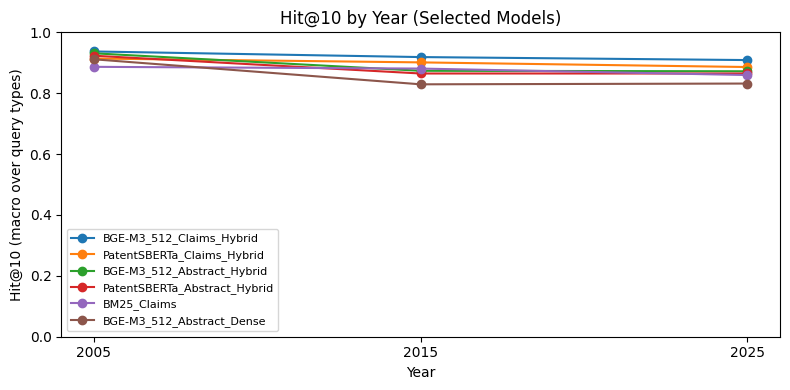

Saved: 2nd_exp\results\notebook05_reporting\appendix_fig_hit10_by_year_selected.png
Saved: 2nd_exp\results\notebook05_reporting\manuscript_table_3way_weights.csv
Saved: 2nd_exp\results\notebook05_reporting\manuscript_table_3way_weights.md
Saved: 2nd_exp\results\notebook05_reporting\manuscript_table_3way_weights.png
Saved: 2nd_exp\results\notebook05_reporting\appendix_top10_weights_3way.csv
Saved: 2nd_exp\results\notebook05_reporting\appendix_top10_weights_3way.md
Saved: 2nd_exp\results\notebook05_reporting\appendix_top10_weights_3way.png
Saved: 2nd_exp\results\notebook05_reporting\appendix_delta_type_vs_global_3way.csv
Saved: 2nd_exp\results\notebook05_reporting\appendix_delta_type_vs_global_3way.md

Notebook 05 reporting completed.
All outputs under: 2nd_exp\results\notebook05_reporting


In [2]:
# =========================================
# Notebook 05 — Reporting (Camera-ready)
# =========================================
# INPUTS:
#  - Notebook 03 outputs:
#      2nd_exp/results/notebook03_eval/
#        - results_cellwise_mainweight.csv
#        - table_main_optionA_overall_and_worst.csv
#        - appendix_table_by_year_macro_over_types.csv
#        - appendix_fig_hit10_by_year_selected.png (optional)
#        - appendix_sensitivity_*.csv (optional)
#  - Notebook 04 outputs:
#      2nd_exp/results/notebook04_3way_grid/
#        - best_weights_*.csv
#        - grid_summary_*.csv
#        - details/*.csv
#
# OUTPUTS (saved under 2nd_exp/results/notebook05_reporting/):
#  - manuscript_table_main.csv (+ .md)
#  - manuscript_table_3way_weights.csv (+ .md)
#  - appendix tables/figures (csv/png)
#
# NOTE:
#  IEEE Access typically accepts tables as images or Word tables.
#  Here we produce:
#    (i) CSV (for direct import)
#    (ii) Markdown (for quick checking / later conversion)
#    (iii) PNG table renders (optional)

import os
import re
import json
import math
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

# ----------------------------
# 0) Paths
# ----------------------------
BASE_DIR = "2nd_exp"

NB03_DIR_CANDIDATES = [
    os.path.join(BASE_DIR, "results", "notebook03_eval_2phase"),
    os.path.join(BASE_DIR, "results", "notebook03_eval_v2"),
]

NB03_DIR = None
for d in NB03_DIR_CANDIDATES:
    if os.path.isdir(d):
        NB03_DIR = d
        break
if NB03_DIR is None:
    raise FileNotFoundError(f"Notebook 03 results dir not found. Tried: {NB03_DIR_CANDIDATES}")

NB04_DIR = os.path.join(BASE_DIR, "results", "notebook04_3way_grid")
OUT_DIR  = os.path.join(BASE_DIR, "results", "notebook05_reporting")
os.makedirs(OUT_DIR, exist_ok=True)

print("NB03_DIR:", NB03_DIR)
print("NB04_DIR:", NB04_DIR)
print("OUT_DIR :", OUT_DIR)


# ----------------------------
# 1) Helpers
# ----------------------------
def must_exist(path: str):
    if not os.path.exists(path):
        raise FileNotFoundError(f"File not found: {path}")

def format_mean_ci(mean: float, lo: float, hi: float, digits: int = 3) -> str:
    if pd.isna(mean) or pd.isna(lo) or pd.isna(hi):
        return ""
    return f"{mean:.{digits}f} [{lo:.{digits}f}, {hi:.{digits}f}]"

def save_markdown_table(df: pd.DataFrame, path_md: str, index: bool = False):
    with open(path_md, "w", encoding="utf-8") as f:
        f.write(df.to_markdown(index=index))
        f.write("\n")

def render_table_png(df: pd.DataFrame, out_png: str, title: str = "", font_size: int = 9):
    # simple table rendering (no custom colors by request rule)
    fig, ax = plt.subplots(figsize=(min(16, 0.23*len(df.columns)+4), min(10, 0.26*len(df)+2)))
    ax.axis("off")
    if title:
        ax.set_title(title, fontsize=12, pad=12)
    tbl = ax.table(cellText=df.values,
                   colLabels=df.columns,
                   cellLoc="center",
                   loc="center")
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(font_size)
    tbl.scale(1, 1.3)
    plt.tight_layout()
    plt.savefig(out_png, dpi=300, bbox_inches="tight")
    plt.close(fig)

# ----------------------------
# 2) Load Notebook 03 artifacts
# ----------------------------
cellwise_path = os.path.join(NB03_DIR, "results_cellwise_mainweight.csv")
summary_path  = os.path.join(NB03_DIR, "table_main_optionA_overall_and_worst.csv")
by_year_path  = os.path.join(NB03_DIR, "appendix_table_by_year_macro_over_types.csv")

must_exist(cellwise_path)
must_exist(summary_path)
must_exist(by_year_path)

df_cell = pd.read_csv(cellwise_path)
df_sum  = pd.read_csv(summary_path)
df_year = pd.read_csv(by_year_path)

# ----------------------------
# 3) Main manuscript table (Option A)
#    - show Overall pooled + Worst-year
#    - primary: Hit@10
# ----------------------------
# Sort by Overall_Hit@10 desc (already in df_sum typically)
df_sum = df_sum.sort_values("Overall_Hit@10", ascending=False).reset_index(drop=True)

main_cols = [
    "display_name",
    "Overall_Hit@10", "Overall_MRR@10", "Overall_Hit@50",
    "WorstYear_Hit@10", "WorstYear_MRR@10", "WorstYear_Hit@50"
]
df_main = df_sum[main_cols].copy()

# Optional: round for presentation
for c in main_cols[1:]:
    df_main[c] = df_main[c].map(lambda x: f"{x:.3f}" if pd.notna(x) else "")

# Save
out_main_csv = os.path.join(OUT_DIR, "manuscript_table_main.csv")
out_main_md  = os.path.join(OUT_DIR, "manuscript_table_main.md")
df_main.to_csv(out_main_csv, index=False)
save_markdown_table(df_main, out_main_md, index=False)

print("Saved:", out_main_csv)
print("Saved:", out_main_md)

# Optional: PNG rendering (useful for quick appendix drafting)
out_main_png = os.path.join(OUT_DIR, "manuscript_table_main.png")
render_table_png(df_main, out_main_png, title="Main Results (Option A): Overall pooled & Worst-year")
print("Saved:", out_main_png)

# ----------------------------
# 4) Appendix: cellwise table with CI (Hit@10 primary only)
#    - This is large (9 cells × 12 models) but useful for verification.
# ----------------------------
df_cell_ci = df_cell.copy()
# Create formatted Hit@10 with CI
df_cell_ci["Hit@10 (95% CI)"] = df_cell_ci.apply(
    lambda r: format_mean_ci(r["Hit@10"], r["Hit@10_ci_lo"], r["Hit@10_ci_hi"], digits=3),
    axis=1
)
df_cell_ci["MRR@10 (95% CI)"] = df_cell_ci.apply(
    lambda r: format_mean_ci(r["MRR@10"], r["MRR@10_ci_lo"], r["MRR@10_ci_hi"], digits=3),
    axis=1
)
df_cell_ci["Hit@50 (95% CI)"] = df_cell_ci.apply(
    lambda r: format_mean_ci(r["Hit@50"], r["Hit@50_ci_lo"], r["Hit@50_ci_hi"], digits=3),
    axis=1
)

df_cell_ci_small = df_cell_ci[[
    "year", "query_type", "display_name", "n_queries",
    "Hit@10 (95% CI)", "MRR@10 (95% CI)", "Hit@50 (95% CI)"
]].sort_values(["year", "query_type", "Hit@10 (95% CI)"], ascending=[True, True, False])

out_cell_ci_csv = os.path.join(OUT_DIR, "appendix_cellwise_with_ci.csv")
out_cell_ci_md  = os.path.join(OUT_DIR, "appendix_cellwise_with_ci.md")
df_cell_ci_small.to_csv(out_cell_ci_csv, index=False)
save_markdown_table(df_cell_ci_small.head(60), out_cell_ci_md, index=False)  # md preview only
print("Saved:", out_cell_ci_csv)
print("Saved:", out_cell_ci_md, "(preview first 60 rows)")

# ----------------------------
# 5) Appendix: year-wise macro table (already produced by Notebook 03)
#    - Re-save with consistent naming
# ----------------------------
out_year_csv = os.path.join(OUT_DIR, "appendix_by_year_macro_over_types.csv")
df_year.to_csv(out_year_csv, index=False)
print("Saved:", out_year_csv)

# Plot: Hit@10 by year for top models + baseline
# (No custom colors; default matplotlib)
topN = 6
top_models = df_sum["model_id"].head(topN).tolist()
if "BM25_CLAIMS" in df_sum["model_id"].values:
    if "BM25_CLAIMS" not in top_models:
        top_models.append("BM25_CLAIMS")

plot_df = df_year[df_year["model_id"].isin(top_models)].copy()
plt.figure(figsize=(8, 4))
for mid in top_models:
    sub = plot_df[plot_df["model_id"] == mid].sort_values("year")
    if len(sub) == 0:
        continue
    plt.plot(sub["year"].values, sub["Hit@10"].values, marker="o", label=sub["display_name"].iloc[0])
plt.xticks(sorted(df_year["year"].unique().tolist()))
plt.ylim(0, 1)
plt.xlabel("Year")
plt.ylabel("Hit@10 (macro over query types)")
plt.title("Hit@10 by Year (Selected Models)")
plt.legend(fontsize=8, loc="best")
plt.tight_layout()
out_year_fig = os.path.join(OUT_DIR, "appendix_fig_hit10_by_year_selected.png")
plt.savefig(out_year_fig, dpi=300)
plt.show()
print("Saved:", out_year_fig)

# ----------------------------
# 6) Load Notebook 04 artifacts (3-way grid search)
# ----------------------------
# We need to locate best_weights_*.csv and grid_summary_*.csv automatically
best_files = [f for f in os.listdir(NB04_DIR) if f.startswith("best_weights_") and f.endswith(".csv")]
grid_files = [f for f in os.listdir(NB04_DIR) if f.startswith("grid_summary_") and f.endswith(".csv")]

if len(best_files) == 0:
    print("[WARN] No best_weights_*.csv found in Notebook 04 directory. Skipping 3-way reporting.")
else:
    best_path = os.path.join(NB04_DIR, best_files[0])  # assume single run; if multiple, pick first
    must_exist(best_path)
    df_best_w = pd.read_csv(best_path)

    # manuscript table: global + per type weights
    # Columns expected:
    #   tag, weight_dense, weight_sparse, weight_colbert, Overall_*, WorstYear_*
    cols_w = [
        "tag", "weight_dense", "weight_sparse", "weight_colbert",
        "Overall_Hit@10", "Overall_MRR@10", "Overall_Hit@50",
        "WorstYear_Hit@10", "WorstYear_MRR@10", "WorstYear_Hit@50"
    ]
    df_w_main = df_best_w[cols_w].copy()

    # format numeric
    for c in ["weight_dense", "weight_sparse", "weight_colbert"]:
        df_w_main[c] = df_w_main[c].map(lambda x: f"{x:.2f}" if pd.notna(x) else "")
    for c in cols_w[4:]:
        df_w_main[c] = df_w_main[c].map(lambda x: f"{x:.3f}" if pd.notna(x) else "")

    out_w_csv = os.path.join(OUT_DIR, "manuscript_table_3way_weights.csv")
    out_w_md  = os.path.join(OUT_DIR, "manuscript_table_3way_weights.md")
    df_w_main.to_csv(out_w_csv, index=False)
    save_markdown_table(df_w_main, out_w_md, index=False)
    print("Saved:", out_w_csv)
    print("Saved:", out_w_md)

    out_w_png = os.path.join(OUT_DIR, "manuscript_table_3way_weights.png")
    render_table_png(df_w_main, out_w_png, title="3-way Grid Search: Best Weights (Global vs Type-specific)")
    print("Saved:", out_w_png)

    # grid summary (optional) — useful for appendix: show top 10 weights
    if len(grid_files) > 0:
        grid_path = os.path.join(NB04_DIR, grid_files[0])
        must_exist(grid_path)
        df_grid = pd.read_csv(grid_path)

        # Keep top-10 by Overall_Hit@10
        df_top10 = df_grid.sort_values("Overall_Hit@10", ascending=False).head(10).copy()
        # format
        df_top10["weight_dense"] = df_top10["weight_dense"].map(lambda x: f"{x:.2f}")
        df_top10["weight_sparse"] = df_top10["weight_sparse"].map(lambda x: f"{x:.2f}")
        df_top10["weight_colbert"] = df_top10["weight_colbert"].map(lambda x: f"{x:.2f}")
        for c in ["Overall_Hit@10","WorstYear_Hit@10","Overall_MRR@10","WorstYear_MRR@10","Overall_Hit@50","WorstYear_Hit@50"]:
            if c in df_top10.columns:
                df_top10[c] = df_top10[c].map(lambda x: f"{x:.3f}")

        out_top10_csv = os.path.join(OUT_DIR, "appendix_top10_weights_3way.csv")
        out_top10_md  = os.path.join(OUT_DIR, "appendix_top10_weights_3way.md")
        df_top10.to_csv(out_top10_csv, index=False)
        save_markdown_table(df_top10, out_top10_md, index=False)
        print("Saved:", out_top10_csv)
        print("Saved:", out_top10_md)

        out_top10_png = os.path.join(OUT_DIR, "appendix_top10_weights_3way.png")
        render_table_png(df_top10, out_top10_png, title="Appendix: Top-10 Weight Candidates (3-way)")
        print("Saved:", out_top10_png)

    # Optional: summarize how much type-specific weights improve over global
    # (Delta = TYPE_qt Overall_Hit@10 - GLOBAL Overall_Hit@10)
    df_global = df_best_w[df_best_w["tag"]=="GLOBAL"].copy()
    if len(df_global) == 1:
        g_hit10 = float(df_global["Overall_Hit@10"].iloc[0])
        g_mrr10 = float(df_global["Overall_MRR@10"].iloc[0])
        g_hit50 = float(df_global["Overall_Hit@50"].iloc[0])

        rows = []
        for qt in ["summary","keyword","function"]:
            sub = df_best_w[df_best_w["tag"]==f"TYPE_{qt}"]
            if len(sub)==1:
                rows.append({
                    "query_type": qt,
                    "Global_w": f"({df_global['weight_dense'].iloc[0]:.2f},{df_global['weight_sparse'].iloc[0]:.2f},{df_global['weight_colbert'].iloc[0]:.2f})",
                    "Type_w": f"({sub['weight_dense'].iloc[0]:.2f},{sub['weight_sparse'].iloc[0]:.2f},{sub['weight_colbert'].iloc[0]:.2f})",
                    "Delta_Overall_Hit@10": float(sub["Overall_Hit@10"].iloc[0]) - g_hit10,
                    "Delta_Overall_MRR@10": float(sub["Overall_MRR@10"].iloc[0]) - g_mrr10,
                    "Delta_Overall_Hit@50": float(sub["Overall_Hit@50"].iloc[0]) - g_hit50,
                })
        if rows:
            df_delta = pd.DataFrame(rows)
            for c in ["Delta_Overall_Hit@10","Delta_Overall_MRR@10","Delta_Overall_Hit@50"]:
                df_delta[c] = df_delta[c].map(lambda x: f"{x:+.3f}")
            out_delta_csv = os.path.join(OUT_DIR, "appendix_delta_type_vs_global_3way.csv")
            out_delta_md  = os.path.join(OUT_DIR, "appendix_delta_type_vs_global_3way.md")
            df_delta.to_csv(out_delta_csv, index=False)
            save_markdown_table(df_delta, out_delta_md, index=False)
            print("Saved:", out_delta_csv)
            print("Saved:", out_delta_md)

print("\nNotebook 05 reporting completed.")
print("All outputs under:", OUT_DIR)


In [1]:
!pip install matplotlib tabulate

  Using cached tabulate-0.9.0-py3-none-any.whl.metadata (34 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ----------- ---------------------------- 2.4/8.1 MB 12.3 MB/s eta 0:00:01
   ------------------------ --------------- 5.0/8.1 MB 12.1 MB/s eta 0:00:01
   ------------------------------------ --- 7.3/8.1 MB 11.9 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 11.4 MB/s  0:00:00
Using cached tabulate-0.9.0-py3-none-any.whl (35 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 1.6/1.6 MB 11.8 MB/s  0:00:00
   ---------------------------------------- 0.0/7.0 MB ? eta -:--:--
   ------------- -------------------------- 2.4/7.0 MB 12.2 MB/s eta 0:00:01
   -------------------------- ------------- 4.7/7.0 MB 11.4 MB/s eta 0:00:01
   -----------------------